In [1]:
## activate packages required
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report

In [3]:
# Load the data
loandata = pd.read_csv('LoanData.csv')
loandata.shape

(149391, 11)

In [5]:
loandata.groupby(['SeriousDlqin2yrs']).size()
## loandata.groupby(['SeriousDlqin2yrs']).size() / loandata.shape[0]

SeriousDlqin2yrs
0    139382
1     10009
dtype: int64

In [8]:
## Define the DV & IV (Step-1 of ML Model)
X = loandata.drop(['SeriousDlqin2yrs'], axis=1)
Y = loandata.SeriousDlqin2yrs

In [9]:
## Split the data into training and test data (Step-2 of ML Model)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state = 91)
X.shape, Y.shape, X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((149391, 10), (149391,), (104573, 10), (44818, 10), (104573,), (44818,))

In [10]:
## Define the ML mOdel to use (Step-3 of ML Modelling)
model = LogisticRegression()

In [11]:
## Estimate the coefficients or fit the model (Step-4 of ML)
model.fit(X_train, Y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [17]:
# Predict the values based on model (Step-5 of ML Model)
predictions = model.predict(X_test)

[0 0 0 ... 0 0 0]


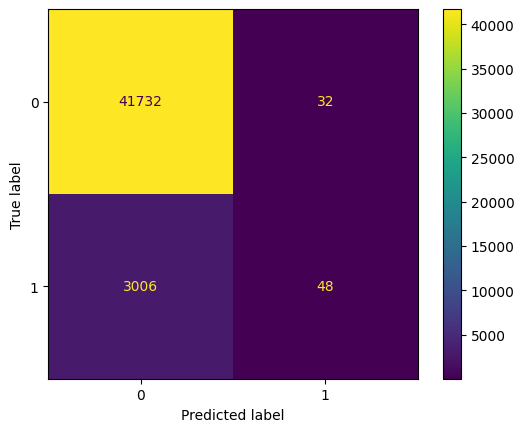

In [19]:
## COnfusion Matrix
cm = ConfusionMatrixDisplay(confusion_matrix(Y_test, predictions)).plot()

In [21]:
report = classification_report(Y_test, predictions)
print("Classification Report")
print(report)

Classification Report
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     41764
           1       0.60      0.02      0.03      3054

    accuracy                           0.93     44818
   macro avg       0.77      0.51      0.50     44818
weighted avg       0.91      0.93      0.90     44818

